init_lake_area_threshold: 100 km² → 2621 cells at 195.31 m resolution
compute_mfd_weights took 0.06 seconds
detect_sea took 0.01 seconds


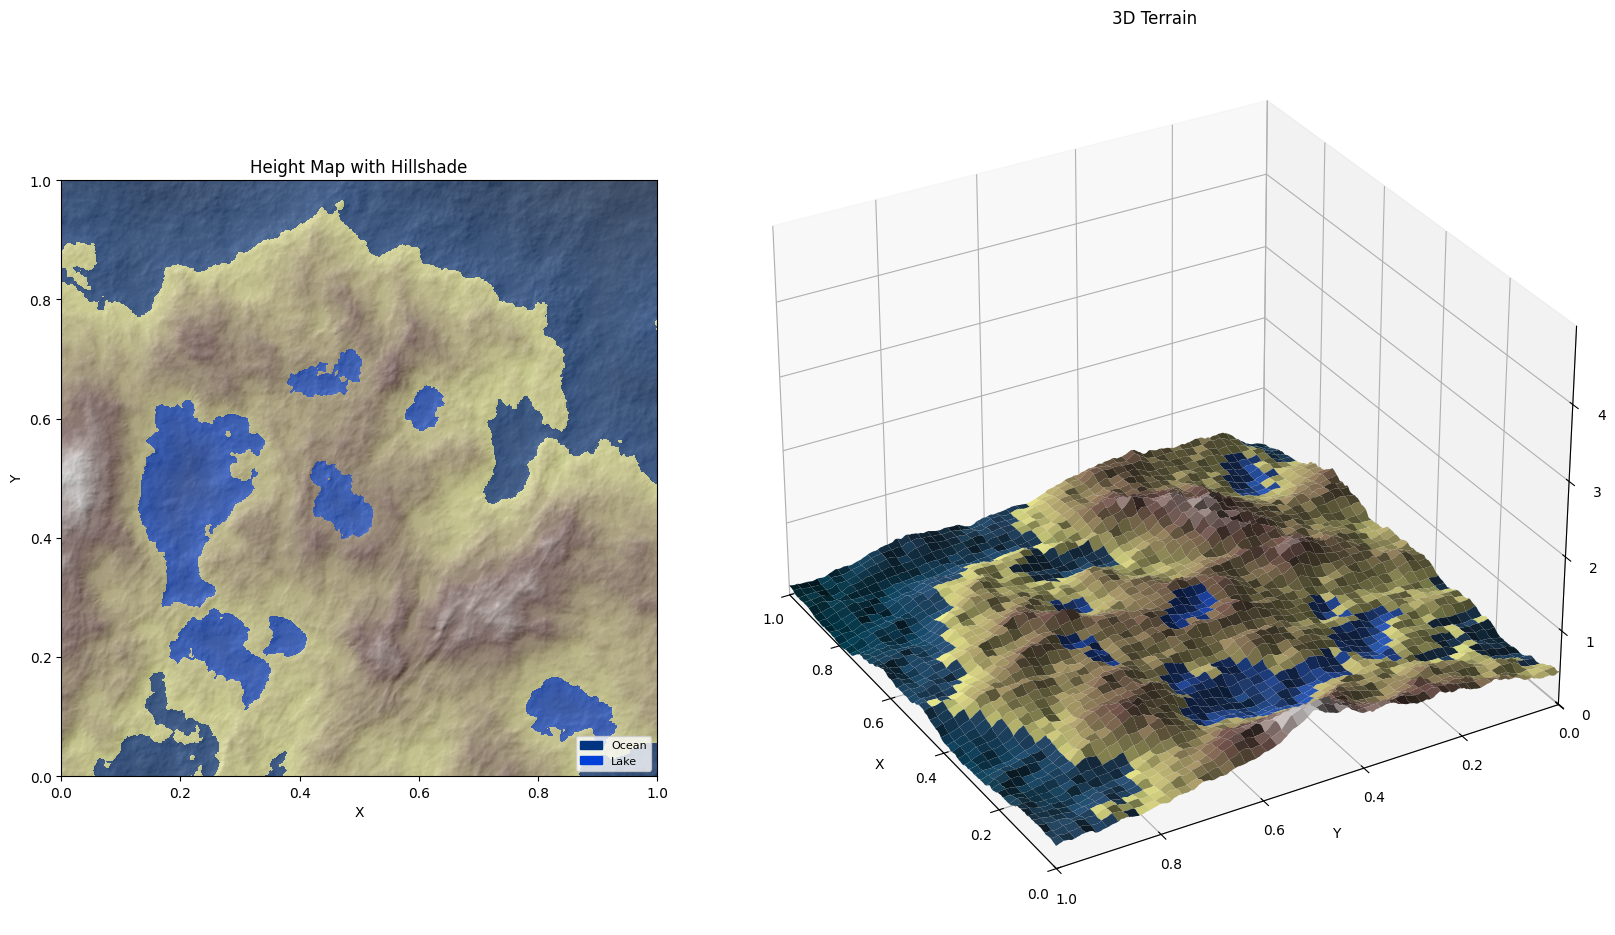

_build_wind_field took 0.07 seconds
_compute_temperature took 0.09 seconds
_compute_temperature took 0.00 seconds
_compute_humidity_and_orog_precip took 2.53 seconds
_compute_precipitation took 0.04 seconds


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from terraLod import Terrain
from terraLod.parameters import world_params

seed = 62
world_params['seed'] = seed

t = Terrain(world_params=world_params)

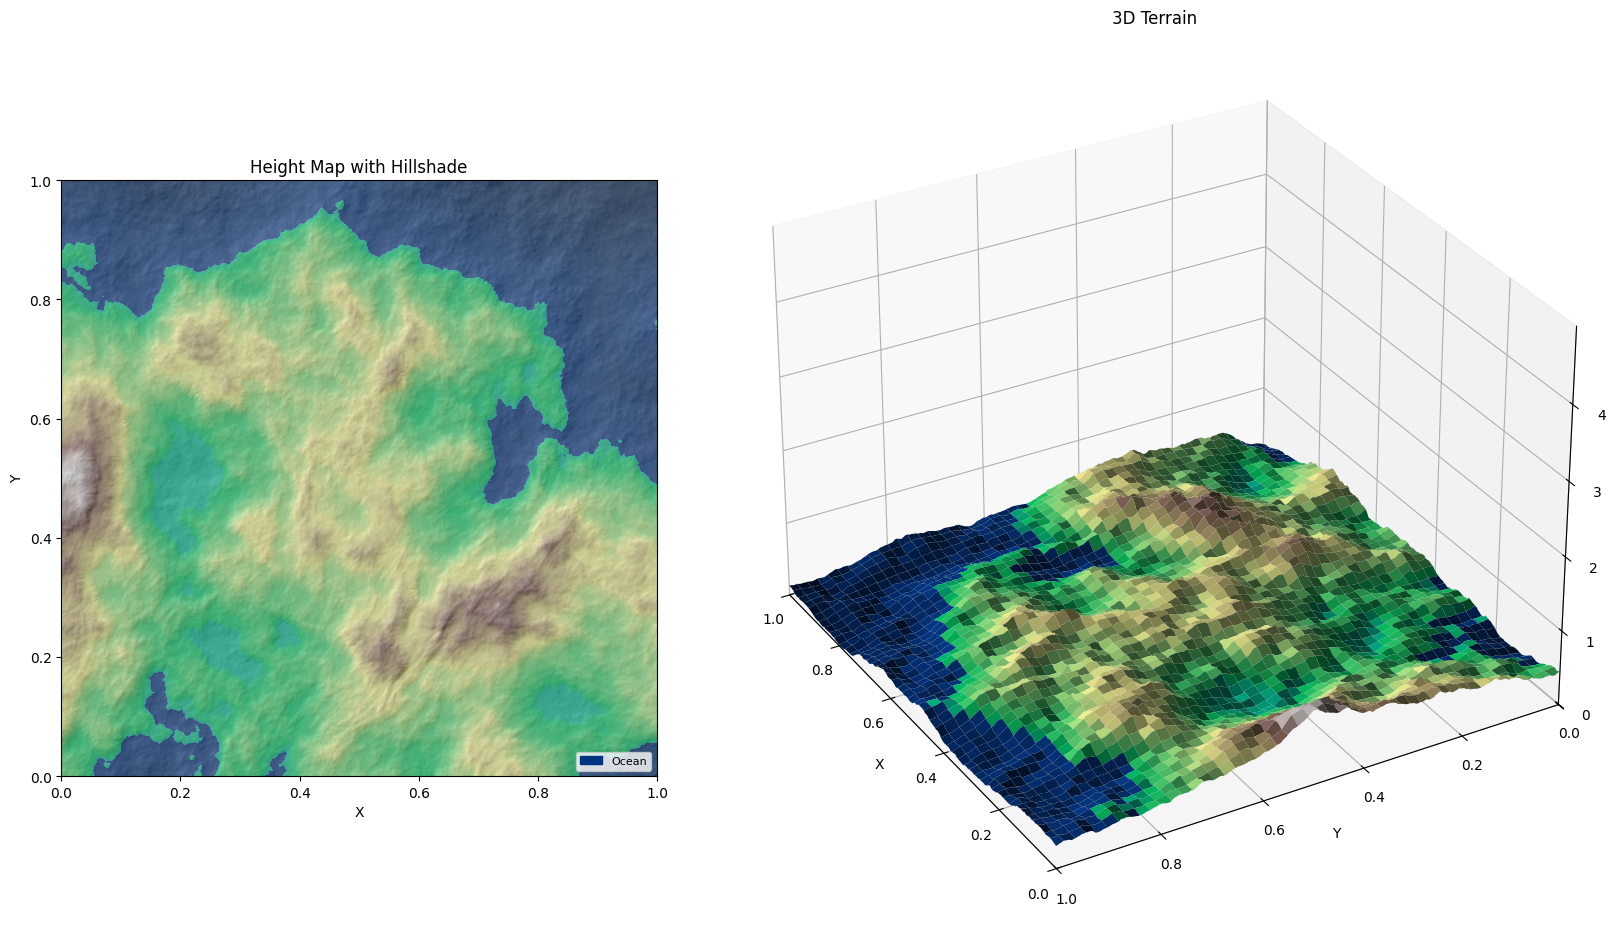

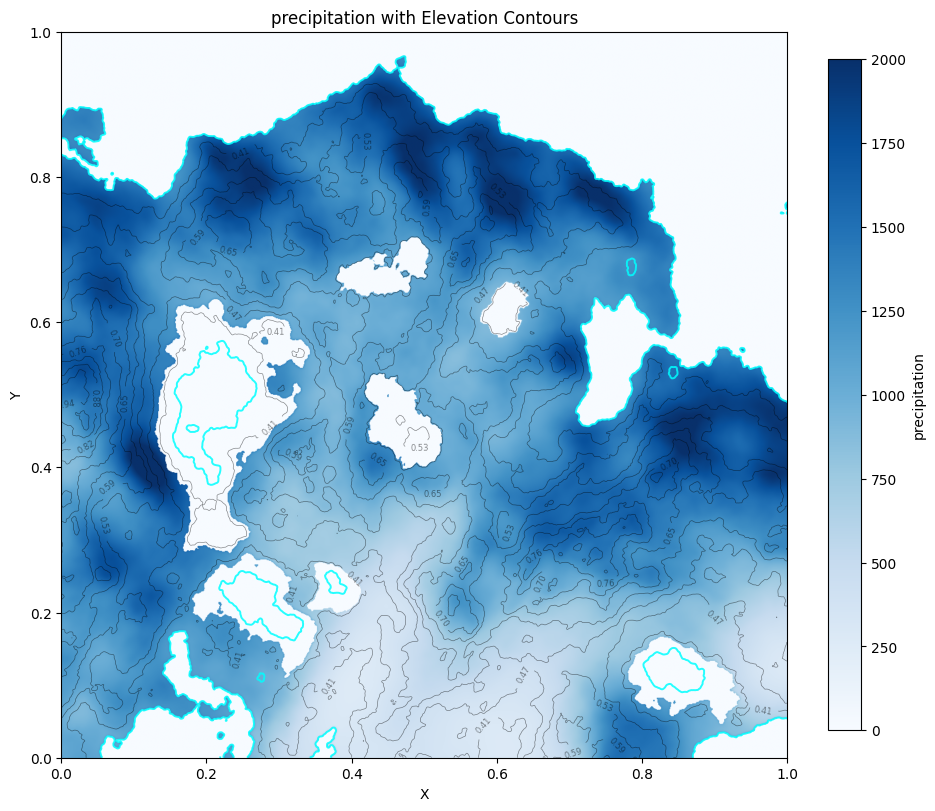

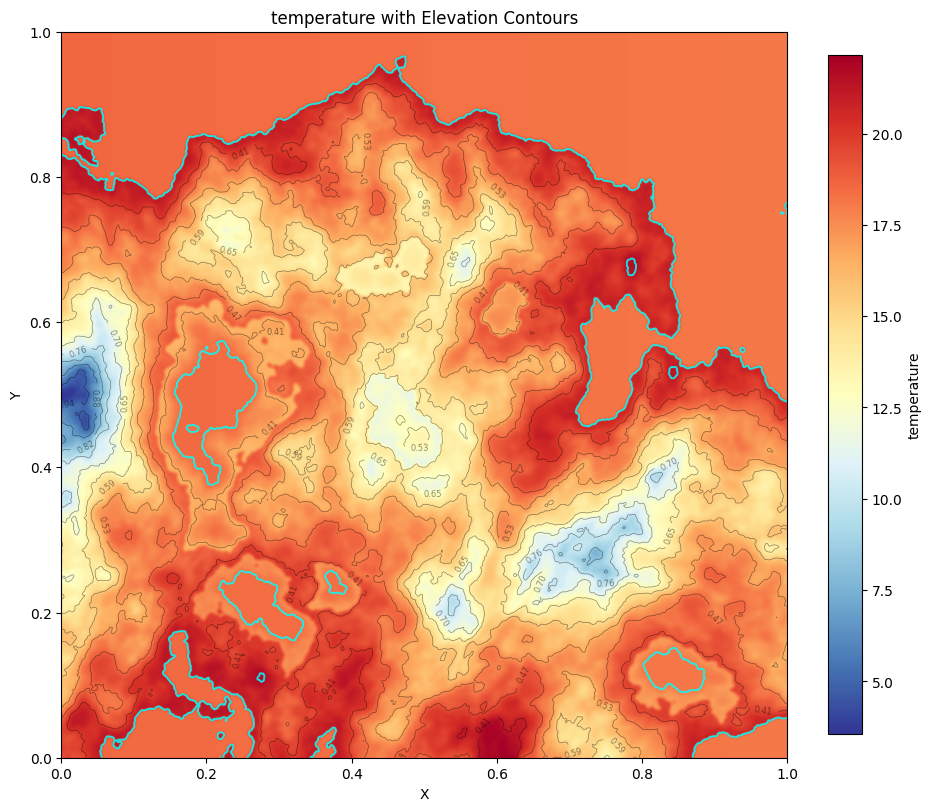

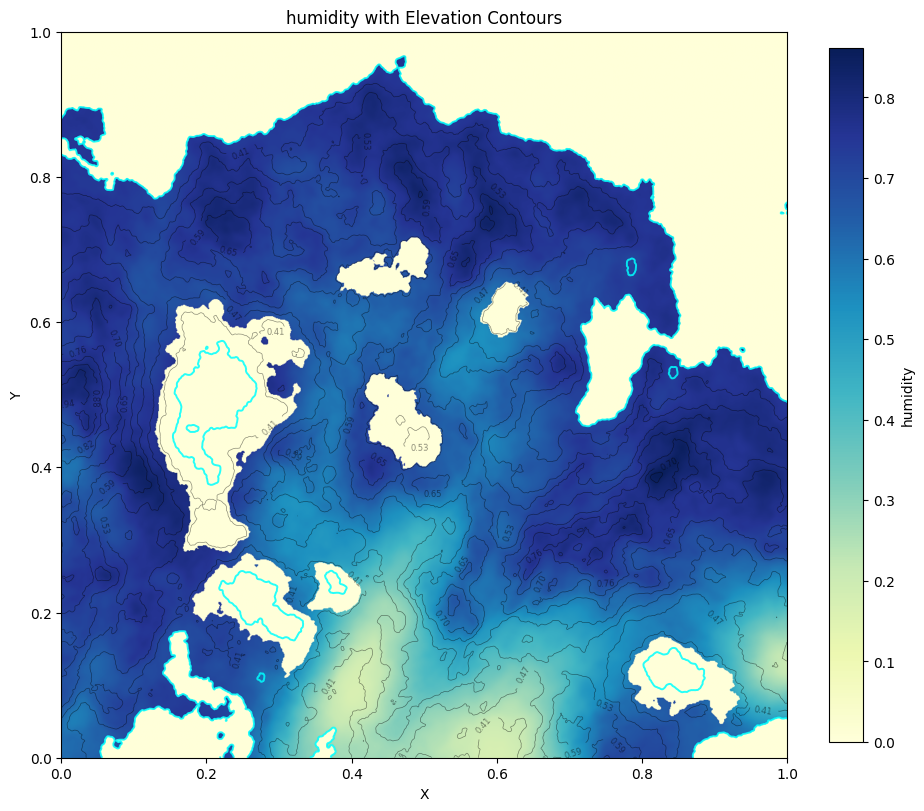

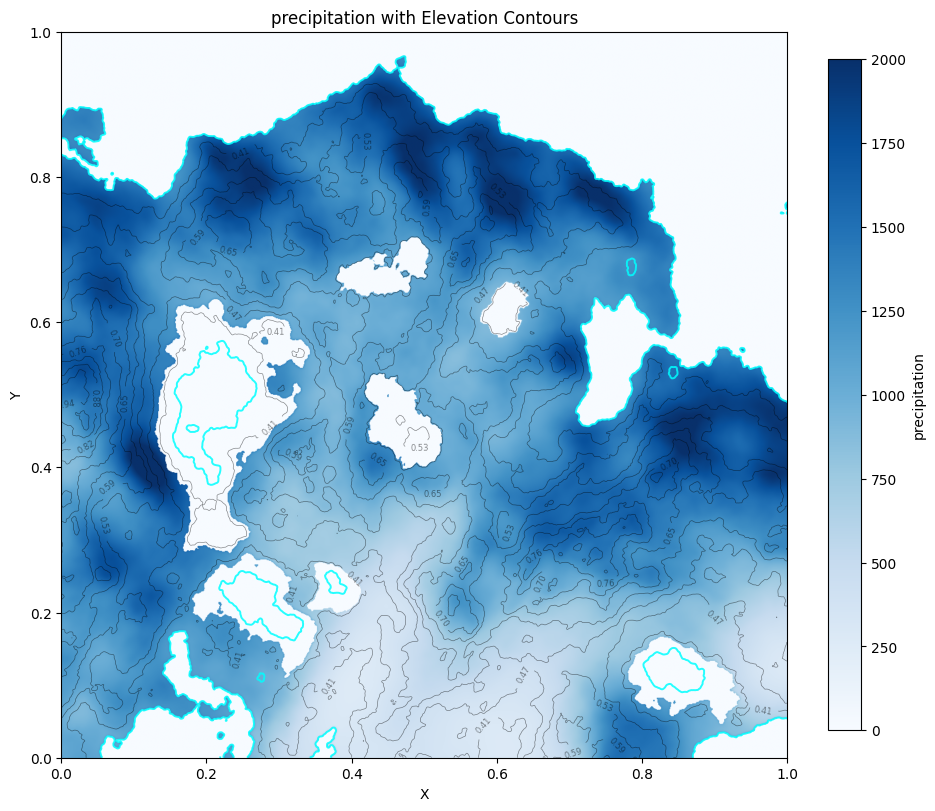

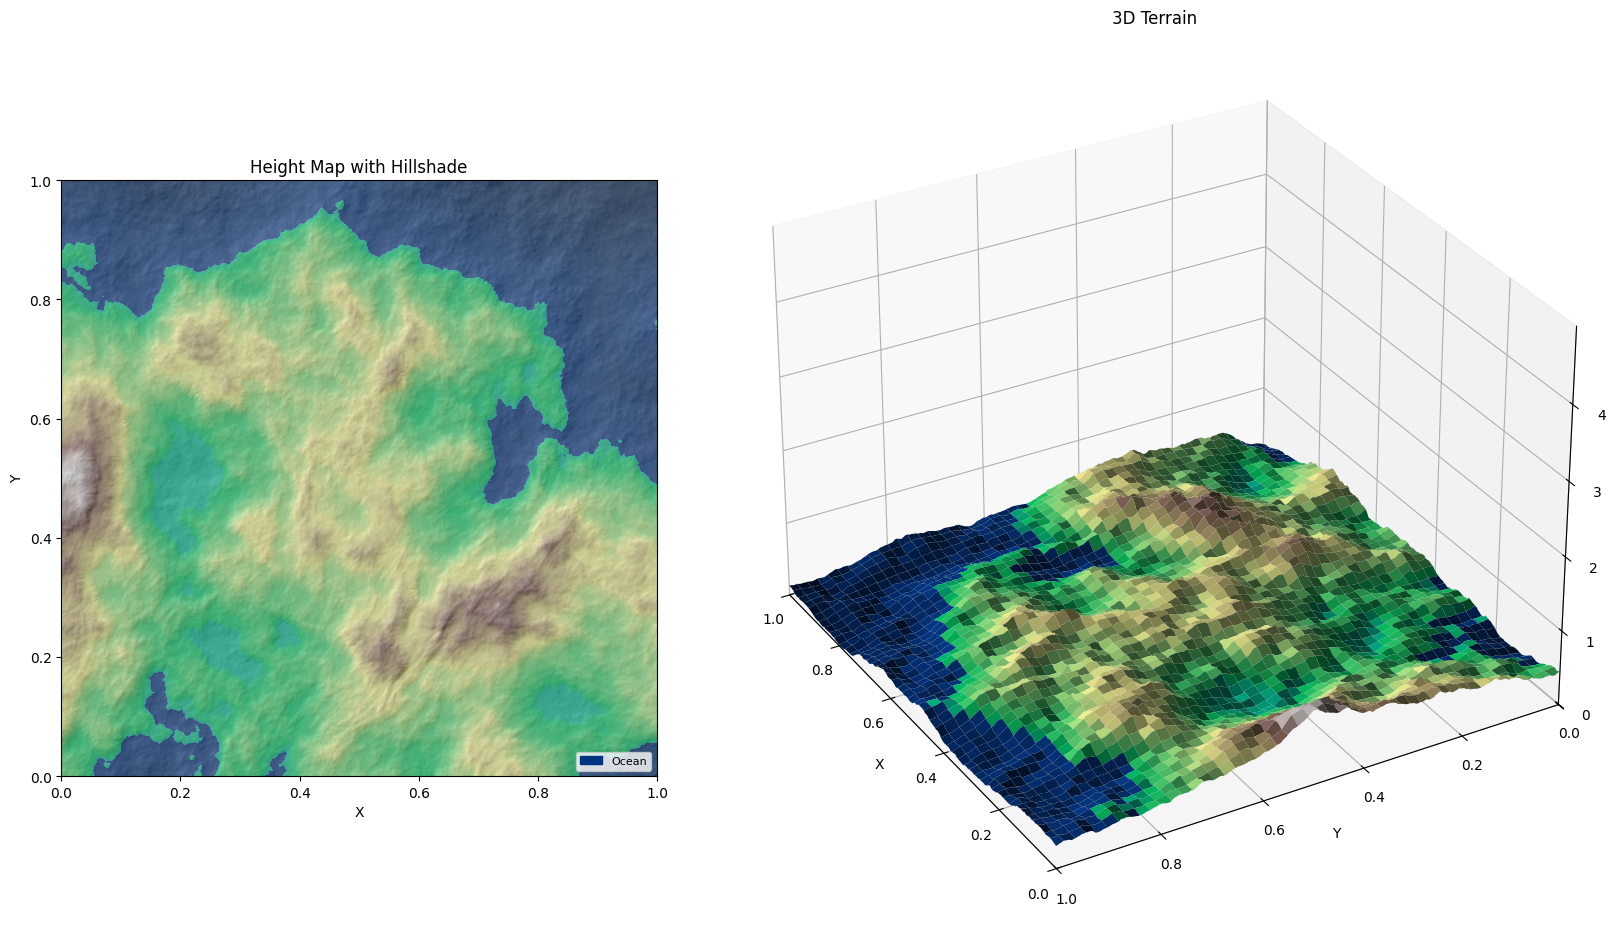

In [2]:
hmap = t.generate()

hmap.plot()                    # existing terrain view (2D + 3D)
hmap.plot('precipitation')     # precipitation map
hmap.plot('temperature')       # temperature map
hmap.plot('humidity')          # humidity map
hmap.plot('precipitation')     # precipitation map
hmap.plot('height')            # same as hmap.plot()

In [8]:
t.climate.precipitation_map.max()

np.float32(1.0)

Zooming in with resolution 100.00 km, lim: (0, 1, 0, 1)


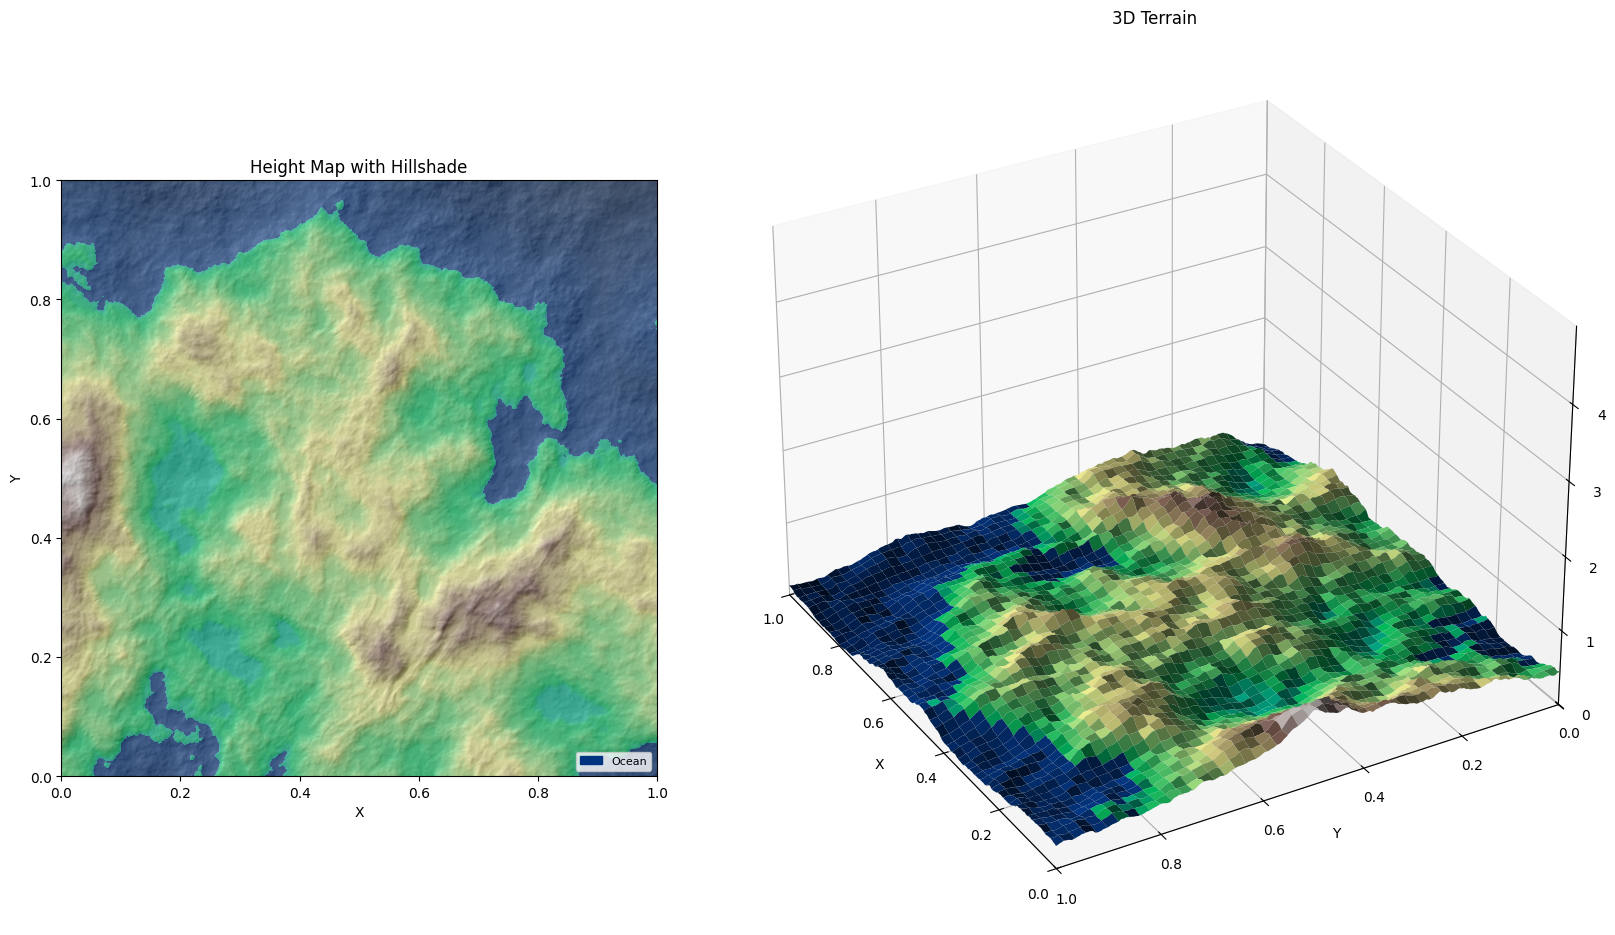

In [ ]:

cx, cy = 0.825, 0.555
width = 1

max_width = 100 #km

while width > 0.007:
    #keep zooming in by halving the width of the view
    #respect the boundaries of the world (0, 1)
    #however do not clip but translate the view if it goes out of bounds, so that we can still zoom in on edges and corners
    x_min = max(0, cx - width/2)
    x_max = min(1, cx + width/2)
    y_min = max(0, cy - width/2)
    y_max = min(1, cy + width/2)

    #translate if out of bounds
    if x_min == 0:
        x_max = min(1, x_max + (width/2 - cx))
    if x_max == 1:
        x_min = max(0, x_min - (cx + width/2 - 1))
    if y_min == 0:
        y_max = min(1, y_max + (width/2 - cy))
    if y_max == 1:
        y_min = max(0, y_min - (cy + width/2 - 1))

    lim = (x_min, x_max, y_min, y_max)
    print(f"Zooming in with resolution {width*max_width:.2f} km, lim: {lim}")
    hmap = t.generate(lim=lim)
    hmap.plot(plot_slope_histogram=True)
    width /= 3.33